In [1]:
import pandas as pd

DATA_PATH = "../../data/processed/zone_hour_clusters.parquet"

df = pd.read_parquet(DATA_PATH)
df.head()

,zone_id,pickup_hour_ts,demand,avg_fare,avg_distance,hour,day_of_week,is_weekend,day,month,cluster
0,1,2019-01-01 10:00:00,2,61.25,16.90,10,1,0,1,1,3
1,1,2019-01-01 12:00:00,1,135.00,19.30,12,1,0,1,1,3
2,1,2019-01-01 15:00:00,1,106.00,41.28,15,1,0,1,1,3
3,1,2019-01-02 02:00:00,1,30.00,1.27,2,2,0,2,1,1
4,1,2019-01-02 03:00:00,1,15.00,12.65,3,2,0,2,1,1


### Cluster Profiling Summary

To translate clusters into business personas, we first construct a numerical summary of each cluster.

This includes:
- demand intensity
- pricing characteristics
- trip distance
- temporal patterns

This step ensures that persona definitions are grounded in data rather than subjective interpretation.

In [2]:
cluster_summary = df.groupby("cluster").agg({
    "demand": ["mean", "median"],
    "avg_fare": "mean",
    "avg_distance": "mean",
    "hour": "mean",
    "is_weekend": "mean"
}).round(2)

cluster_summary

demand        avg_fare avg_distance   hour is_weekend
           mean median     mean         mean   mean       mean
cluster                                                       
0        409.41  370.0    11.43         2.40  15.36       0.11
1         31.76    6.0    14.52         3.58  11.18       0.00
2         56.02    8.0    14.72         3.71  11.38       1.00
3         15.65    1.0    48.16        14.24  11.92       0.17

### Relative Positioning of Clusters

To better understand cluster differences, we rank clusters across key dimensions such as demand, fare, and distance.

This highlights which clusters represent extreme behaviors (e.g., highest demand or longest trips).

In [3]:
summary_flat = cluster_summary.copy()
summary_flat.columns = ["_".join(col) for col in summary_flat.columns]

rank_df = summary_flat.rank(ascending=False)

rank_df

,demand_mean,demand_median,avg_fare_mean,avg_distance_mean,hour_mean,is_weekend_mean
cluster,,,,,,
0,1.0,1.0,4.0,4.0,1.0,3.0
1,3.0,3.0,3.0,3.0,4.0,4.0
2,2.0,2.0,2.0,2.0,3.0,1.0
3,4.0,4.0,1.0,1.0,2.0,2.0


### Persona Naming Framework

Each cluster is translated into a business persona using the following structure:

[Demand Level] + [Temporal Pattern] + [Economic Characteristics]

This ensures that names are:
- descriptive
- consistent
- interpretable by non-technical stakeholders

### Business Personas

Each cluster is assigned a descriptive business persona that captures its demand behavior and operational meaning.

In [4]:
persona_mapping = {
    0: "Off-Peak Low Demand Activity",
    1: "Peak Hour Core Demand",
    2: "Baseline Mixed Activity",
    3: "High-Value Long-Distance Trips"
}

df["persona"] = df["cluster"].map(persona_mapping)

In [5]:
df

,zone_id,pickup_hour_ts,demand,avg_fare,avg_distance,hour,day_of_week,is_weekend,day,month,cluster,persona
0,1,2019-01-01 10:00:00,2,61.250,16.900,10,1,0,1,1,3,High-Value Long-Distance Trips
1,1,2019-01-01 12:00:00,1,135.000,19.300,12,1,0,1,1,3,High-Value Long-Distance Trips
2,1,2019-01-01 15:00:00,1,106.000,41.280,15,1,0,1,1,3,High-Value Long-Distance Trips
3,1,2019-01-02 02:00:00,1,30.000,1.270,2,2,0,2,1,1,Peak Hour Core Demand
4,1,2019-01-02 03:00:00,1,15.000,12.650,3,2,0,2,1,1,Peak Hour Core Demand
...,...,...,...,...,...,...,...,...,...,...,...,...
296802,265,2019-03-31 19:00:00,4,61.625,5.015,19,6,1,31,3,2,Baseline Mixed Activity
296803,265,2019-03-31 20:00:00,5,96.700,30.746,20,6,1,31,3,3,High-Value Long-Distance Trips
296804,265,2019-03-31 21:00:00,1,36.780,14.690,21,6,1,31,3,3,High-Value Long-Distance Trips
296805,265,2019-03-31 22:00:00,2,19.235,6.475,22,6,1,31,3,2,Baseline Mixed Activity


## Business Personas

### 1. Off-Peak Low Demand Activity

This persona represents periods of low taxi demand, typically occurring during late-night and early-morning hours.

Trips are shorter and lower in value, and activity is relatively sparse. These conditions are characteristic of residential or peripheral areas during non-peak times.

From an operational perspective, this segment reflects background demand and may require reduced driver allocation.

---

### 2. Peak Hour Core Demand

This persona captures the highest intensity demand periods, concentrated during weekday peak hours.

Ride volumes are significantly elevated, reflecting commuting patterns and central business district activity.

This segment is critical for operational planning, as it represents the largest share of total rides and requires optimal driver supply and dynamic pricing strategies.

---

### 3. Baseline Mixed Activity

This persona represents stable, moderate demand levels across a wide range of hours.

Trips exhibit average characteristics in terms of fare and distance, and no strong temporal dominance is observed.

This segment reflects the underlying baseline demand of the city and provides a steady contribution to overall ride volume.

---

### 4. High-Value Long-Distance Trips

This persona captures lower-frequency but economically significant trips, characterized by longer distances and higher fares.

These trips are more common during weekends and off-peak periods, suggesting leisure or airport-related travel.

Despite lower volume, this segment contributes disproportionately to revenue and is important for pricing and service strategy.

### Persona Validation

We visualize key features across personas to confirm that they represent distinct demand behaviors.

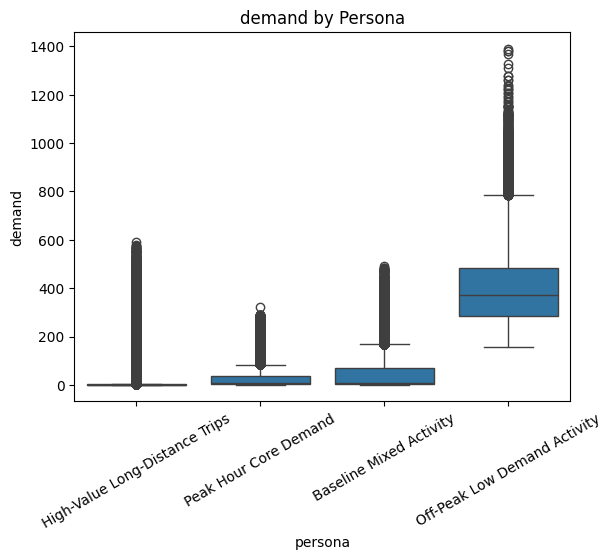

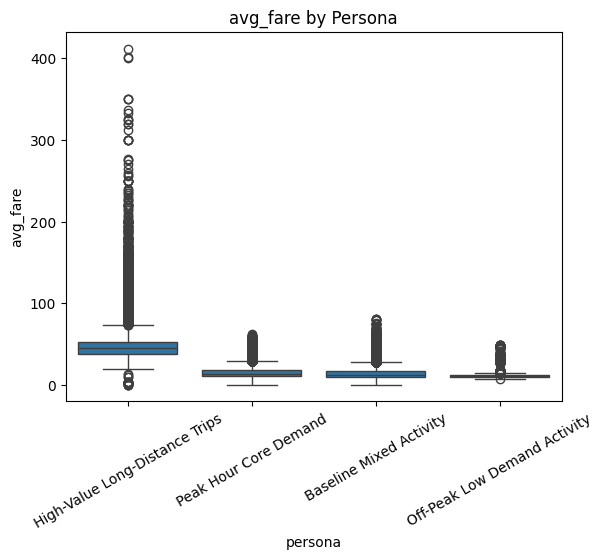

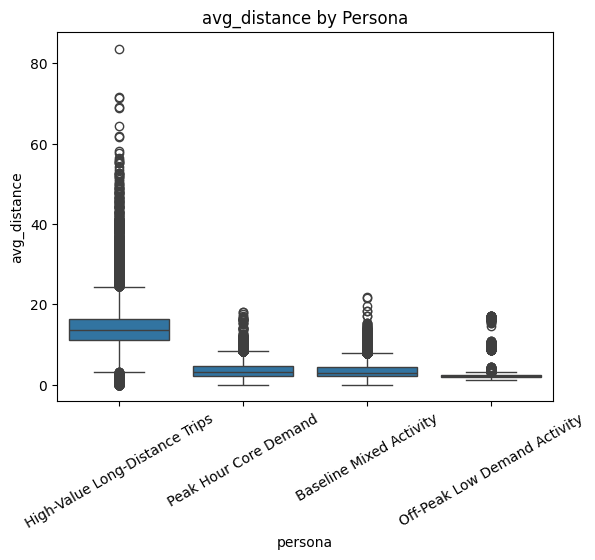

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["demand", "avg_fare", "avg_distance"]

for feature in features:
    plt.figure()
    sns.boxplot(x="persona", y=feature, data=df)
    plt.xticks(rotation=30)
    plt.title(f"{feature} by Persona")
    plt.show()

## Final Persona Interpretation

The clustering analysis reveals four distinct demand personas that characterize urban taxi activity:

- Off-peak low-demand periods represent background system usage
- Peak-hour demand captures the core operational load of the system
- Baseline activity reflects stable, city-wide demand patterns
- High-value trips represent economically significant but less frequent rides

These personas provide a structured view of demand heterogeneity and can be directly used for:

- demand forecasting segmentation
- pricing strategy
- driver allocation optimization

By translating clusters into business personas, the analysis becomes actionable and aligned with real-world decision-making.